Objetivo: Implementar el pipeline completo del Support Vector Classifier para clasificación binaria de tendencias (BUY/SELL), incluyendo preprocesamiento, ingeniería de características, entrenamiento con GridSearchCV, predicción y cálculo de métricas.

Referencia de investigación doctoral: Este notebook debe inspirarse en el notebook de investigación del profesor: 26_05_07_V03E(enFISI)_SVM_Trend_Grid_Optimization_ECR.ipynb, que implementa un sistema multi-empresa de SVM con optimización por GridSearch sobre los 5 tickers del estudio.

Frontend destino: ernesto_investing_svc_clasificador.html (Clasificador SVC de tendencia bursátil con gráfico de precios y marcadores BUY/SELL, panel de métricas (Accuracy, F1, Precision, Recall), matriz de confusión y semáforo de señal. Consume el JSON generado por el Notebook 2.)

# 📈 SVC Clasificador de Tendencia Bursátil
## Pipeline Completo: Ingeniería de Características → GridSearchCV → JSON Export

**Investigación Doctoral** — Prof. E. D. Cancho-Rodríguez, MBA (GWU) · iDeSo · UNMSM

**Tickers estudiados:** FSM · VOLCABC1.LM · ABX.TO · BVN · BHP

**Output:** `datos_svc.json` — Compatible con `ernesto_investing_svc_clasificador.html`

---
| Módulo | Descripción |
|--------|-------------|
| 1 | Instalación y librerías |
| 2 | Descarga de datos OHLCV con yfinance |
| 3 | Ingeniería de características técnicas |
| 4 | Variable objetivo (Trend) + normalización |
| 5 | Partición temporal train/test |
| 6 | Entrenamiento con GridSearchCV |
| 7 | Evaluación y métricas |
| 8 | Exportación a datos_svc.json |


# Modulo 1: Instalación de dependencias

In [6]:
# Instalación de librerías necesarias
# ta: Technical Analysis Library para indicadores bursátiles
!pip install yfinance ta --quiet

# Modulo 2: Importación de Librerías

In [7]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import json
import yfinance as yf
from datetime import datetime, timedelta

# Indicadores técnicos
import ta
from ta.trend import SMAIndicator, EMAIndicator, MACD
from ta.momentum import RSIIndicator, StochasticOscillator
from ta.volatility import BollingerBands, AverageTrueRange

# Machine Learning
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
from sklearn.pipeline import Pipeline

# Visualización
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

print('✅ Librerías importadas correctamente')
print(f'   numpy  {np.__version__}')
print(f'   pandas {pd.__version__}')
print(f'   ta     ')


✅ Librerías importadas correctamente
   numpy  2.0.2
   pandas 2.2.2
   ta     


# Modulo 3: Configuración Global del Estudio

In [8]:
# ═══════════════════════════════════════════════════════════════════════
# PARÁMETROS GLOBALES DEL PIPELINE
# ═══════════════════════════════════════════════════════════════════════

# Tickers del estudio doctoral (sector minero con operaciones en Perú)
TICKERS = ['FSM', 'VOLCABC1.LM', 'ABX.TO', 'BVN', 'BHP']

# Metadatos de cada empresa
EMPRESAS_META = {
    'FSM':         {'nombre': 'Fortuna Silver Mines',       'moneda': 'USD'},
    'VOLCABC1.LM': {'nombre': 'Volcan Compañia Minera',     'moneda': 'PEN'},
    'ABX.TO':      {'nombre': 'Barrick Gold Corporation',   'moneda': 'CAD'},
    'BVN':         {'nombre': 'Buenaventura Mining',        'moneda': 'USD'},
    'BHP':         {'nombre': 'BHP Group Limited',          'moneda': 'USD'},
}

# Período de descarga de datos
FECHA_INICIO = '2020-01-01'   # Mínimo 4 años para robustez estadística
FECHA_FIN    = datetime.today().strftime('%Y-%m-%d')

# Horizonte de predicción: cuántos días adelante define la tendencia
HORIZONTE_PREDICCION = 5   # 5 días hábiles ≈ 1 semana

# Partición temporal (sin data leakage)
RATIO_TRAIN = 0.80

# GridSearchCV — espacio de hiperparámetros
PARAM_GRID = {
    'svc__kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
    'svc__C':      [0.1, 1, 10, 100],
    'svc__gamma':  ['scale', 'auto'],
}
CV_FOLDS = 5   # TimeSeriesSplit — respeta orden temporal

print('✅ Configuración global establecida')
print(f'   Tickers   : {TICKERS}')
print(f'   Período   : {FECHA_INICIO} → {FECHA_FIN}')
print(f'   Horizonte : {HORIZONTE_PREDICCION} días')
print(f'   Train/Test: {int(RATIO_TRAIN*100)}/{int((1-RATIO_TRAIN)*100)}%')
print(f'   CV folds  : {CV_FOLDS} (TimeSeriesSplit)')


✅ Configuración global establecida
   Tickers   : ['FSM', 'VOLCABC1.LM', 'ABX.TO', 'BVN', 'BHP']
   Período   : 2020-01-01 → 2026-06-14
   Horizonte : 5 días
   Train/Test: 80/19%
   CV folds  : 5 (TimeSeriesSplit)


# Modulo 4: Descarga de Datos OHLCV

Descarga de datos históricos desde Yahoo Finance usando `yfinance`.
Se verifican datos mínimos y se reportan fechas disponibles por ticker.


In [9]:
# ═══════════════════════════════════════════════════════════════════════
# DESCARGA DE DATOS OHLCV CON YFINANCE
# ═══════════════════════════════════════════════════════════════════════

datos_raw = {}   # Diccionario: ticker → DataFrame OHLCV limpio

print('📡 Descargando datos históricos de Yahoo Finance...\n')
print(f'   Período: {FECHA_INICIO} → {FECHA_FIN}\n')

for ticker in TICKERS:
    print(f'   ⬇  {ticker:<14s}', end=' ')
    try:
        df = yf.download(ticker, start=FECHA_INICIO, end=FECHA_FIN,
                         auto_adjust=True, progress=False)

        # Aplanar MultiIndex si yfinance lo genera
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)

        # Renombrar columnas a nombres estándar
        df = df.rename(columns={
            'Open': 'Open', 'High': 'High', 'Low': 'Low',
            'Close': 'Close', 'Volume': 'Volume'
        })
        df = df[['Open', 'High', 'Low', 'Close', 'Volume']].copy()
        df.index = pd.to_datetime(df.index)
        df.sort_index(inplace=True)

        # Eliminar filas con cierre nulo o cero
        df = df[df['Close'] > 0].dropna(subset=['Close'])

        n = len(df)
        if n < 200:
            print(f'⚠️  Solo {n} registros — puede afectar calidad del modelo')
        else:
            print(f'✅ {n:>4d} registros  [{df.index[0].date()} → {df.index[-1].date()}]')

        datos_raw[ticker] = df

    except Exception as e:
        print(f'❌ Error: {e}')

print(f'\n✅ {len(datos_raw)}/{len(TICKERS)} tickers descargados correctamente')


📡 Descargando datos históricos de Yahoo Finance...

   Período: 2020-01-01 → 2026-06-14

   ⬇  FSM            ✅ 1620 registros  [2020-01-02 → 2026-06-12]
   ⬇  VOLCABC1.LM    ✅ 1610 registros  [2020-01-02 → 2026-06-12]
   ⬇  ABX.TO         ✅ 1619 registros  [2020-01-02 → 2026-06-12]
   ⬇  BVN            ✅ 1620 registros  [2020-01-02 → 2026-06-12]
   ⬇  BHP            ✅ 1620 registros  [2020-01-02 → 2026-06-12]

✅ 5/5 tickers descargados correctamente


# Modulo 5: Ingeniería de Características Técnicas

Se calculan indicadores técnicos usando la librería `ta`:
- **Tendencia:** SMA(10,20,50), EMA(12,26), MACD
- **Momentum:** RSI(14), Stochastic Oscillator(14), Rate of Change
- **Volatilidad:** Bollinger Bands(20), ATR(14), Volatilidad histórica
- **Precio/Volumen:** Retornos logarítmicos, Momentum de precio


In [10]:
def calcular_caracteristicas(df):
    """
    Calcula el conjunto completo de características técnicas sobre un DataFrame OHLCV.
    Retorna un DataFrame con las características más la columna objetivo 'Trend'.
    No usa valores futuros — respeta orden temporal estrictamente.
    """
    df = df.copy()

    # ── RETORNOS ─────────────────────────────────────────────────────────────
    # Retorno logarítmico del día: log(P_t / P_{t-1})
    df['retorno_log']    = np.log(df['Close'] / df['Close'].shift(1))
    df['retorno_1d']     = df['Close'].pct_change(1)
    df['retorno_3d']     = df['Close'].pct_change(3)
    df['retorno_5d']     = df['Close'].pct_change(5)
    df['retorno_10d']    = df['Close'].pct_change(10)

    # ── MEDIAS MÓVILES SIMPLES (SMA) ─────────────────────────────────────────
    for ventana in [10, 20, 50]:
        sma = SMAIndicator(close=df['Close'], window=ventana)
        df[f'sma_{ventana}']       = sma.sma_indicator()
        df[f'precio_sma_{ventana}'] = df['Close'] / df[f'sma_{ventana}'] - 1  # Ratio precio/SMA

    # ── MEDIAS MÓVILES EXPONENCIALES (EMA) ───────────────────────────────────
    for ventana in [12, 26]:
        ema = EMAIndicator(close=df['Close'], window=ventana)
        df[f'ema_{ventana}'] = ema.ema_indicator()

    # Cruce EMA rápida/lenta (señal clásica de tendencia)
    df['ema_cruce'] = df['ema_12'] / df['ema_26'] - 1

    # ── MACD ─────────────────────────────────────────────────────────────────
    macd_ind = MACD(close=df['Close'],
                    window_slow=26, window_fast=12, window_sign=9)
    df['macd']         = macd_ind.macd()
    df['macd_signal']  = macd_ind.macd_signal()
    df['macd_hist']    = macd_ind.macd_diff()   # Histograma MACD

    # ── RSI ──────────────────────────────────────────────────────────────────
    rsi_ind = RSIIndicator(close=df['Close'], window=14)
    df['rsi_14'] = rsi_ind.rsi()

    # Zonas de sobrecompra/sobreventa
    df['rsi_zona_alta']  = (df['rsi_14'] > 70).astype(int)  # Sobrecompra
    df['rsi_zona_baja']  = (df['rsi_14'] < 30).astype(int)  # Sobreventa

    # ── STOCHASTIC OSCILLATOR ─────────────────────────────────────────────────
    stoch = StochasticOscillator(high=df['High'], low=df['Low'],
                                 close=df['Close'], window=14, smooth_window=3)
    df['stoch_k'] = stoch.stoch()
    df['stoch_d'] = stoch.stoch_signal()

    # ── BOLLINGER BANDS ───────────────────────────────────────────────────────
    bb = BollingerBands(close=df['Close'], window=20, window_dev=2)
    df['bb_upper']  = bb.bollinger_hband()
    df['bb_lower']  = bb.bollinger_lband()
    df['bb_middle'] = bb.bollinger_mavg()
    df['bb_width']  = bb.bollinger_wband()   # Ancho de banda (volatilidad)
    df['bb_pct_b']  = bb.bollinger_pband()   # %B: posición del precio en la banda

    # ── ATR (Average True Range) ──────────────────────────────────────────────
    atr = AverageTrueRange(high=df['High'], low=df['Low'],
                           close=df['Close'], window=14)
    df['atr_14']     = atr.average_true_range()
    df['atr_pct']    = df['atr_14'] / df['Close']  # ATR normalizado por precio

    # ── VOLATILIDAD HISTÓRICA ─────────────────────────────────────────────────
    # Desviación estándar rodante de retornos logarítmicos
    df['volatilidad_10d'] = df['retorno_log'].rolling(10).std() * np.sqrt(252)
    df['volatilidad_20d'] = df['retorno_log'].rolling(20).std() * np.sqrt(252)

    # ── MOMENTUM DE PRECIO ────────────────────────────────────────────────────
    df['momentum_5']  = df['Close'] - df['Close'].shift(5)
    df['momentum_10'] = df['Close'] - df['Close'].shift(10)

    # Rate of Change (ROC)
    df['roc_5']  = (df['Close'] - df['Close'].shift(5))  / df['Close'].shift(5)  * 100
    df['roc_10'] = (df['Close'] - df['Close'].shift(10)) / df['Close'].shift(10) * 100

    # ── HIGH-LOW RANGE ────────────────────────────────────────────────────────
    df['rango_hl']     = (df['High'] - df['Low']) / df['Close']   # Rango diario normalizado
    df['rango_hl_5d']  = df['rango_hl'].rolling(5).mean()

    # ── VOLUMEN ───────────────────────────────────────────────────────────────
    df['vol_ratio']    = df['Volume'] / df['Volume'].rolling(20).mean()  # Volumen relativo
    df['vol_cambio']   = df['Volume'].pct_change()

    # ═══════════════════════════════════════════════════════════════════════
    # VARIABLE OBJETIVO: Trend (1=BUY, 0=SELL)
    # REGLA: Si el precio de cierre sube en los próximos HORIZONTE_PREDICCION
    # días hábiles → BUY (1); si baja o igual → SELL (0)
    # IMPORTANTE: usamos shift(-HORIZONTE_PREDICCION) para mirar hacia adelante,
    # pero durante entrenamiento NUNCA se dispone de datos futuros —
    # la variable objetivo sólo se calcula sobre el conjunto de entrenamiento
    # y la partición temporal evita leakage.
    # ═══════════════════════════════════════════════════════════════════════
    precio_futuro  = df['Close'].shift(-HORIZONTE_PREDICCION)
    df['Trend']    = (precio_futuro > df['Close']).astype(int)

    return df


# ── Aplicar a todos los tickers ───────────────────────────────────────────────
datos_features = {}   # ticker → DataFrame con características + Trend

print('🔧 Calculando características técnicas...\n')

for ticker in datos_raw:
    df_feat = calcular_caracteristicas(datos_raw[ticker])

    # Eliminar filas con NaN (período de calentamiento de indicadores)
    n_antes = len(df_feat)
    df_feat = df_feat.dropna()
    n_despues = len(df_feat)

    datos_features[ticker] = df_feat

    print(f'   ✅ {ticker:<14s}  Filas: {n_antes:>4d} → {n_despues:>4d}'
          f'  (descartadas: {n_antes-n_despues})')
    print(f'         Características: {n_despues}  |  '
          f'BUY={df_feat["Trend"].mean()*100:.1f}%  '
          f'SELL={(1-df_feat["Trend"].mean())*100:.1f}%')

print('\n✅ Ingeniería de características completada')


🔧 Calculando características técnicas...

   ✅ FSM             Filas: 1620 → 1571  (descartadas: 49)
         Características: 1571  |  BUY=51.3%  SELL=48.7%
   ✅ VOLCABC1.LM     Filas: 1610 → 1530  (descartadas: 80)
         Características: 1530  |  BUY=43.8%  SELL=56.2%
   ✅ ABX.TO          Filas: 1619 → 1570  (descartadas: 49)
         Características: 1570  |  BUY=52.3%  SELL=47.7%
   ✅ BVN             Filas: 1620 → 1571  (descartadas: 49)
         Características: 1571  |  BUY=51.9%  SELL=48.1%
   ✅ BHP             Filas: 1620 → 1571  (descartadas: 49)
         Características: 1571  |  BUY=54.2%  SELL=45.8%

✅ Ingeniería de características completada


In [11]:
""" Lista de características utilizadas """

# Columnas que se usarán como features (excluir OHLCV crudas y objetivo)
COLUMNAS_EXCLUIR = ['Open', 'High', 'Low', 'Close', 'Volume', 'Trend',
                    'sma_10', 'sma_20', 'sma_50',   # Excluir SMAs absolutas
                    'ema_12', 'ema_26',              # Excluir EMAs absolutas
                    'bb_upper', 'bb_lower', 'bb_middle',  # Excluir bandas absolutas
                    'macd', 'macd_signal',           # Conservar solo histograma
                    'atr_14',                        # Conservar solo ATR%
                    'momentum_5', 'momentum_10'      # Excluir momentum absoluto
                    ]

# Definir lista final de features usando el primer ticker como referencia
ticker_ref = list(datos_features.keys())[0]
FEATURES = [c for c in datos_features[ticker_ref].columns
            if c not in COLUMNAS_EXCLUIR]

print(f'📊 Total de características: {len(FEATURES)}\n')
print('Características seleccionadas:')
for i, f in enumerate(FEATURES, 1):
    print(f'   {i:2d}. {f}')


📊 Total de características: 26

Características seleccionadas:
    1. retorno_log
    2. retorno_1d
    3. retorno_3d
    4. retorno_5d
    5. retorno_10d
    6. precio_sma_10
    7. precio_sma_20
    8. precio_sma_50
    9. ema_cruce
   10. macd_hist
   11. rsi_14
   12. rsi_zona_alta
   13. rsi_zona_baja
   14. stoch_k
   15. stoch_d
   16. bb_width
   17. bb_pct_b
   18. atr_pct
   19. volatilidad_10d
   20. volatilidad_20d
   21. roc_5
   22. roc_10
   23. rango_hl
   24. rango_hl_5d
   25. vol_ratio
   26. vol_cambio


# Modulo 6: Partición Temporal Train/Test 80/20

> **Sin data leakage:** la partición se realiza respetando el orden cronológico.
> El conjunto de test nunca se usa durante el entrenamiento ni la optimización.


In [12]:
# ═══════════════════════════════════════════════════════════════════════
# PARTICIÓN TEMPORAL — respeta orden cronológico estrictamente
# ═══════════════════════════════════════════════════════════════════════

particiones = {}  # ticker → {'X_train', 'X_test', 'y_train', 'y_test', ...}

print('✂️  Particionando datos train/test (80/20) por fecha...\n')
print(f'   {"Ticker":<14s}  {"Train":<8s}  {"Test":<8s}  '
      f'{"Fecha corte":<12s}  {"Buy% train":<10s}  {"Buy% test"}')
print('   ' + '─'*70)

for ticker, df in datos_features.items():

    n = len(df)
    corte = int(n * RATIO_TRAIN)

    df_train = df.iloc[:corte].copy()
    df_test  = df.iloc[corte:].copy()

    X_train = df_train[FEATURES].values
    y_train = df_train['Trend'].values
    X_test  = df_test[FEATURES].values
    y_test  = df_test['Trend'].values

    fecha_corte = df_train.index[-1].strftime('%Y-%m-%d')
    buy_train   = y_train.mean() * 100
    buy_test    = y_test.mean()  * 100

    particiones[ticker] = {
        'X_train': X_train, 'y_train': y_train,
        'X_test':  X_test,  'y_test':  y_test,
        'df_train': df_train, 'df_test': df_test,
        'fecha_corte': fecha_corte,
        'n_train': len(df_train), 'n_test': len(df_test)
    }

    print(f'   {ticker:<14s}  {len(df_train):<8d}  {len(df_test):<8d}  '
          f'{fecha_corte:<12s}  {buy_train:<10.1f}%  {buy_test:.1f}%')

print(f'\n✅ Partición completada — {len(particiones)} tickers procesados')


✂️  Particionando datos train/test (80/20) por fecha...

   Ticker          Train     Test      Fecha corte   Buy% train  Buy% test
   ──────────────────────────────────────────────────────────────────────
   FSM             1256      315       2025-03-12    50.2      %  55.6%
   VOLCABC1.LM     1224      306       2025-03-10    40.8      %  55.9%
   ABX.TO          1256      314       2025-03-13    50.6      %  59.2%
   BVN             1256      315       2025-03-12    50.1      %  59.4%
   BHP             1256      315       2025-03-12    53.3      %  58.1%

✅ Partición completada — 5 tickers procesados


# Modulo 7: Entrenamiento con GridSearchCV

**Pipeline:** `StandardScaler` → `SVC`

- **Kernels:** `linear`, `rbf`, `poly`, `sigmoid`
- **C:** `[0.1, 1, 10, 100]`
- **Gamma:** `['scale', 'auto']`
- **Validación cruzada:** `TimeSeriesSplit(5)` — respeta orden temporal
- **Métrica de optimización:** `F1` macro

> ⏱ Este módulo puede tardar **5–15 minutos** en Colab gratuito.
> El espacio de búsqueda completo son **4 × 4 × 2 = 32 combinaciones × 5 folds = 160 ajustes por ticker**.


In [14]:
# ═══════════════════════════════════════════════════════════════════════
# PIPELINE: StandardScaler + SVC
# OPTIMIZACIÓN: GridSearchCV con TimeSeriesSplit
# ═══════════════════════════════════════════════════════════════════════

resultados_svm = {}  # ticker → resultados completos del modelo

print('🤖 Iniciando entrenamiento con GridSearchCV...\n')
print(f'   Espacio de búsqueda: {len(PARAM_GRID["svc__kernel"])} kernels × '
      f'{len(PARAM_GRID["svc__C"])} C × '
      f'{len(PARAM_GRID["svc__gamma"])} gamma = '
      f'{len(PARAM_GRID["svc__kernel"]) * len(PARAM_GRID["svc__C"]) * len(PARAM_GRID["svc__gamma"])} combinaciones')
print(f'   Validación cruzada: TimeSeriesSplit({CV_FOLDS} folds)\n')
print('═' * 70)

# Validación cruzada temporal (preserva orden cronológico)
tscv = TimeSeriesSplit(n_splits=CV_FOLDS)

for ticker in particiones:
    print(f'\n📊 {ticker} — {EMPRESAS_META[ticker]["nombre"]}')
    print(f'   Train: {particiones[ticker]["n_train"]} muestras  |  '
          f'Test: {particiones[ticker]["n_test"]} muestras')

    X_train = particiones[ticker]['X_train']
    y_train = particiones[ticker]['y_train']
    X_test  = particiones[ticker]['X_test']
    y_test  = particiones[ticker]['y_test']

    # --- INICIO DEL PARCHE PARA VALORES NO FINITOS ---
    # StandardScaler requiere que las entradas sean finitas.
    # Reemplazamos infinitos por NaN y luego eliminamos las filas con NaN.

    # Limpieza de X_train y y_train
    original_n_train = len(X_train)
    finite_mask_train = np.ones(original_n_train, dtype=bool)
    if np.isinf(X_train).any() or np.isnan(X_train).any():
        print(f'   ⚠️  {ticker}: detectados valores no finitos en X_train. Limpiando...')
        X_train[np.isinf(X_train)] = np.nan # Convertir inf a NaN

        # Combinar X_train y y_train para asegurar que se eliminan filas correspondientes
        combined_train = np.hstack((X_train, y_train.reshape(-1, 1)))
        finite_mask_train = ~np.isnan(combined_train).any(axis=1)
        cleaned_train = combined_train[finite_mask_train]

        X_train = cleaned_train[:, :-1]
        y_train = cleaned_train[:, -1]

        if len(X_train) < original_n_train:
            print(f'      Se eliminaron {original_n_train - len(X_train)} filas de X_train/y_train.')

        if len(X_train) == 0:
            print(f'   ❌ Error: {ticker} X_train quedó vacío después de la limpieza. Saltando este ticker.')
            continue # Salta al siguiente ticker si no hay datos de entrenamiento

    # Limpieza de X_test y y_test
    original_n_test = len(X_test)
    finite_mask_test = np.ones(original_n_test, dtype=bool)
    if np.isinf(X_test).any() or np.isnan(X_test).any():
        print(f'   ⚠️  {ticker}: detectados valores no finitos en X_test. Limpiando...')
        X_test[np.isinf(X_test)] = np.nan # Convertir inf a NaN

        combined_test = np.hstack((X_test, y_test.reshape(-1, 1)))
        finite_mask_test = ~np.isnan(combined_test).any(axis=1)
        cleaned_test = combined_test[finite_mask_test]

        X_test = cleaned_test[:, :-1]
        y_test = cleaned_test[:, -1]

        if len(X_test) < original_n_test:
            print(f'      Se eliminaron {original_n_test - len(X_test)} filas de X_test/y_test.')

        if len(X_test) == 0:
            print(f'   ❌ Advertencia: {ticker} X_test quedó vacío después de la limpieza. No se calcularán métricas de test para este ticker.')
    # --- FIN DEL PARCHE PARA VALORES NO FINITOS ---


    # ── Construir pipeline ──────────────────────────────────────────────
    pipeline = Pipeline([
        ('scaler', StandardScaler()),   # Normalización
        ('svc',    SVC(probability=True, random_state=42, cache_size=500))
    ])

    # ── GridSearchCV ────────────────────────────────────────────────────
    # Asegúrate de que X_train y y_train no estén vacíos antes de GridSearchCV
    if len(X_train) == 0:
        print(f'   ❌ Error: {ticker} X_train está vacío después de la limpieza. Saltando GridSearchCV para este ticker.')
        continue

    grid_search = GridSearchCV(
        estimator  = pipeline,
        param_grid = PARAM_GRID,
        cv         = tscv,
        scoring    = 'f1_macro',
        n_jobs     = -1,          # Usa todos los núcleos disponibles
        verbose    = 0,
        refit      = True         # Reajusta con los mejores parámetros sobre todos los datos de train
    )

    try:
        grid_search.fit(X_train, y_train)
    except ValueError as e:
        print(f'   ❌ Error durante GridSearchCV.fit para {ticker}: {e}. Saltando este ticker.')
        continue

    # ── Mejor modelo ────────────────────────────────────────────────────
    mejor_modelo    = grid_search.best_estimator_
    mejores_params  = grid_search.best_params_
    mejor_cv_score  = grid_search.best_score_

    kernel_ganador = mejores_params['svc__kernel']
    C_ganador      = mejores_params['svc__C']
    gamma_ganador  = mejores_params['svc__gamma']

    print(f'   ✅ Mejor kernel  : {kernel_ganador}')
    print(f'   ✅ Mejor C       : {C_ganador}')
    print(f'   ✅ Mejor gamma   : {gamma_ganador}')
    print(f'   ✅ CV F1-macro   : {mejor_cv_score:.4f}')

    # ── Predicciones en test ─────────────────────────────────────────────
    # Solo hacer predicciones si X_test no está vacío
    if len(X_test) > 0:
        y_pred       = mejor_modelo.predict(X_test)
        y_prob       = mejor_modelo.predict_proba(X_test)[:, 1]  # Probabilidad de BUY

        # ── Métricas en test ─────────────────────────────────────────────────
        acc   = accuracy_score(y_test, y_pred)
        prec  = precision_score(y_test, y_pred, zero_division=0)
        rec   = recall_score(y_test, y_pred, zero_division=0)
        f1    = f1_score(y_test, y_pred, zero_division=0)
        cm    = confusion_matrix(y_test, y_pred)

        print(f'\n   📋 Métricas en TEST:')
        print(f'      Accuracy  : {acc:.4f}')
        print(f'      Precision : {prec:.4f}')
        print(f'      Recall    : {rec:.4f}')
        print(f'      F1-Score  : {f1:.4f}')

        # ── Señales en test ──────────────────────────────────────────────────
        # Reconstruir df_test_sig usando solo las filas válidas
        original_df_test = particiones[ticker]['df_test']
        df_test_sig = original_df_test[finite_mask_test].copy()

        df_test_sig['prediccion']   = y_pred
        df_test_sig['probabilidad'] = y_prob
        df_test_sig['senal']        = df_test_sig['prediccion'].map({1: 'BUY', 0: 'SELL'})

        resultados_svm[ticker] = {
            'modelo':        mejor_modelo,
            'params':        {'kernel': kernel_ganador, 'C': C_ganador, 'gamma': gamma_ganador},
            'cv_score':      mejor_cv_score,
            'metricas': {
                'accuracy':  round(float(acc),  4),
                'precision': round(float(prec), 4),
                'recall':    round(float(rec),  4),
                'f1':        round(float(f1),   4),
            },
            'confusion_matrix': cm.tolist(),
            'df_test_sig':   df_test_sig,
            'y_pred':        y_pred,
            'y_prob':        y_prob,
        }
    else:
        print(f'   ⚠️  No se calcularon métricas de test para {ticker} debido a la falta de datos en X_test.')
        resultados_svm[ticker] = {
            'modelo':        mejor_modelo,
            'params':        {'kernel': kernel_ganador, 'C': C_ganador, 'gamma': gamma_ganador},
            'cv_score':      mejor_cv_score,
            'metricas':      {},
            'confusion_matrix': [],
            'df_test_sig':   pd.DataFrame(),
            'y_pred':        np.array([]),
            'y_prob':        np.array([]),
        }

print('\n' + '═'*70)
print('✅ GridSearchCV completado para todos los tickers')

🤖 Iniciando entrenamiento con GridSearchCV...

   Espacio de búsqueda: 4 kernels × 4 C × 2 gamma = 32 combinaciones
   Validación cruzada: TimeSeriesSplit(5 folds)

══════════════════════════════════════════════════════════════════════

📊 FSM — Fortuna Silver Mines
   Train: 1256 muestras  |  Test: 315 muestras
   ✅ Mejor kernel  : sigmoid
   ✅ Mejor C       : 100
   ✅ Mejor gamma   : scale
   ✅ CV F1-macro   : 0.4931

   📋 Métricas en TEST:
      Accuracy  : 0.5143
      Precision : 0.5809
      Recall    : 0.4514
      F1-Score  : 0.5080

📊 VOLCABC1.LM — Volcan Compañia Minera
   Train: 1224 muestras  |  Test: 306 muestras
   ⚠️  VOLCABC1.LM: detectados valores no finitos en X_train. Limpiando...
      Se eliminaron 46 filas de X_train/y_train.
   ⚠️  VOLCABC1.LM: detectados valores no finitos en X_test. Limpiando...
      Se eliminaron 14 filas de X_test/y_test.
   ✅ Mejor kernel  : poly
   ✅ Mejor C       : 100
   ✅ Mejor gamma   : scale
   ✅ CV F1-macro   : 0.5088

   📋 Métricas e

# Modulo 8: Evaluación y Visualización

📋 TABLA RESUMEN — MÉTRICAS POR TICKER

   Ticker          Kernel        C  Gamma    Accuracy  Precision   Recall       F1
   ───────────────────────────────────────────────────────────────────────────
   FSM             sigmoid     100  scale      0.5143     0.5809   0.4514   0.5080
   VOLCABC1.LM     poly        100  scale      0.4589     0.5385   0.2561   0.3471
   ABX.TO          sigmoid     100  scale      0.5159     0.6012   0.5430   0.5706
   BVN             rbf          10  scale      0.5556     0.6599   0.5187   0.5808
   BHP             sigmoid     100  scale      0.4730     0.5563   0.4590   0.5030




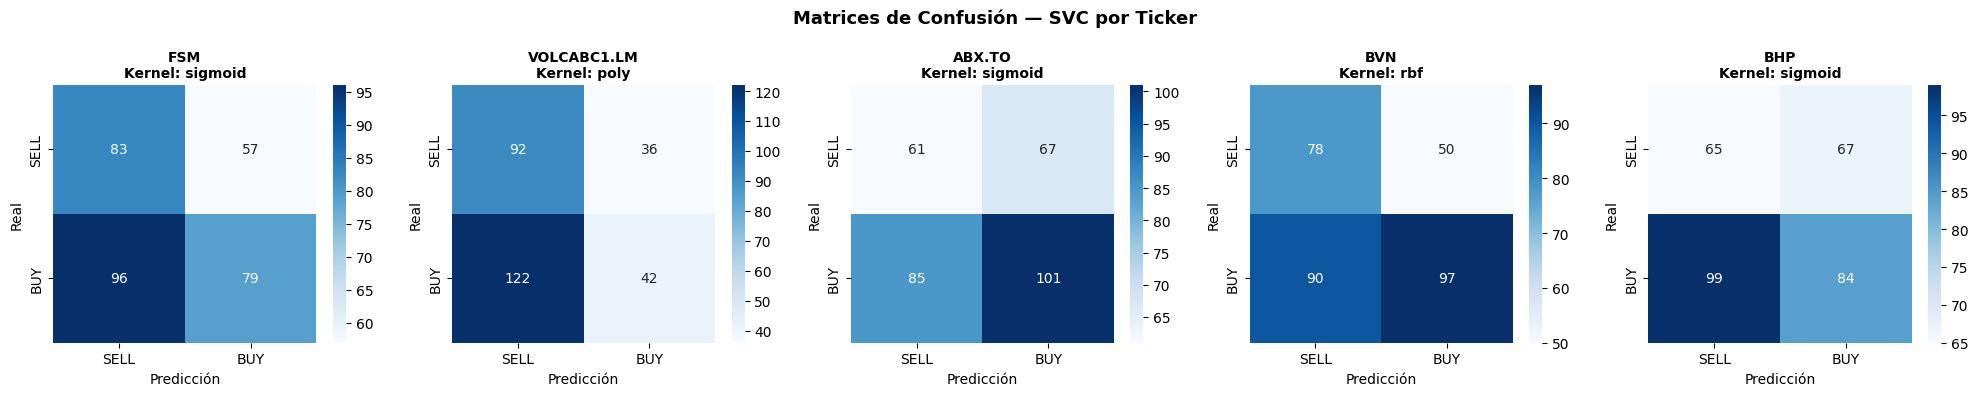

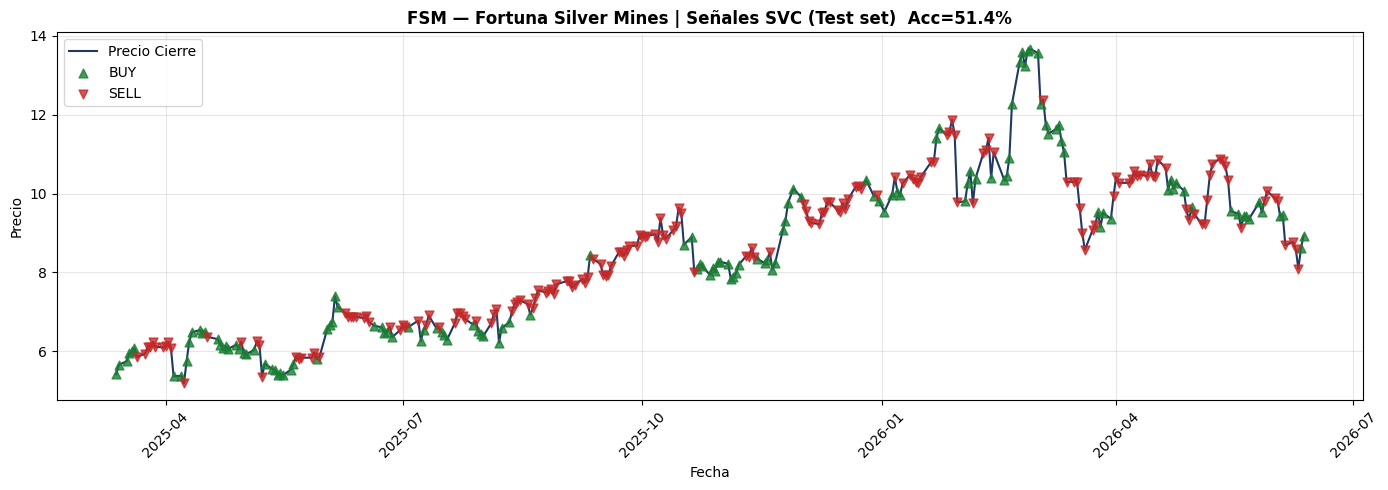

   BUY: 136  SELL: 179    Kernel: sigmoid  C=100  gamma=scale



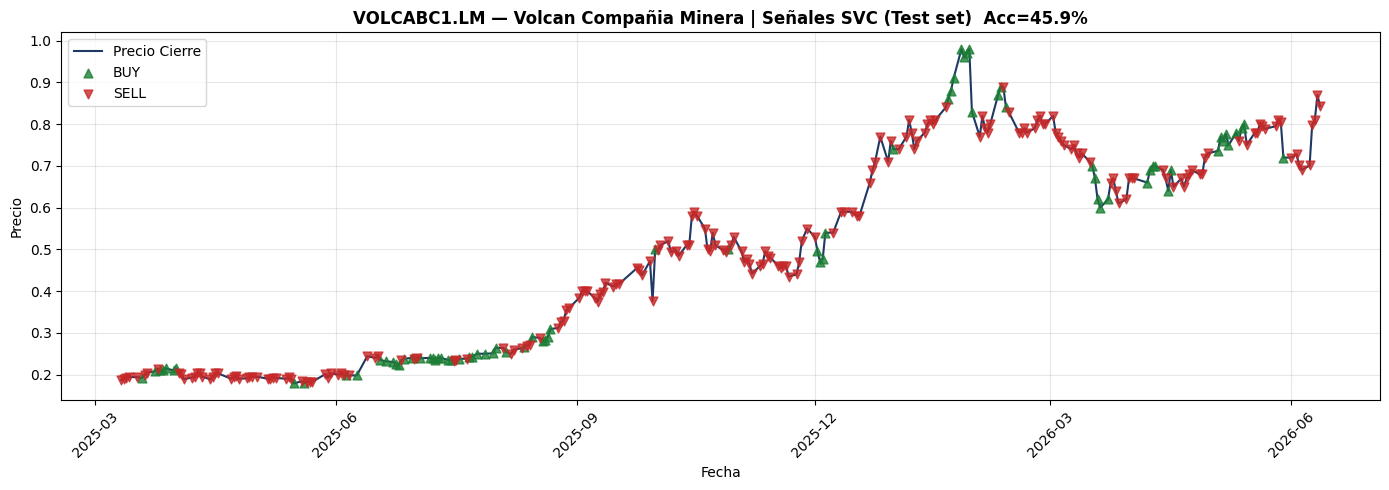

   BUY: 78  SELL: 214    Kernel: poly  C=100  gamma=scale



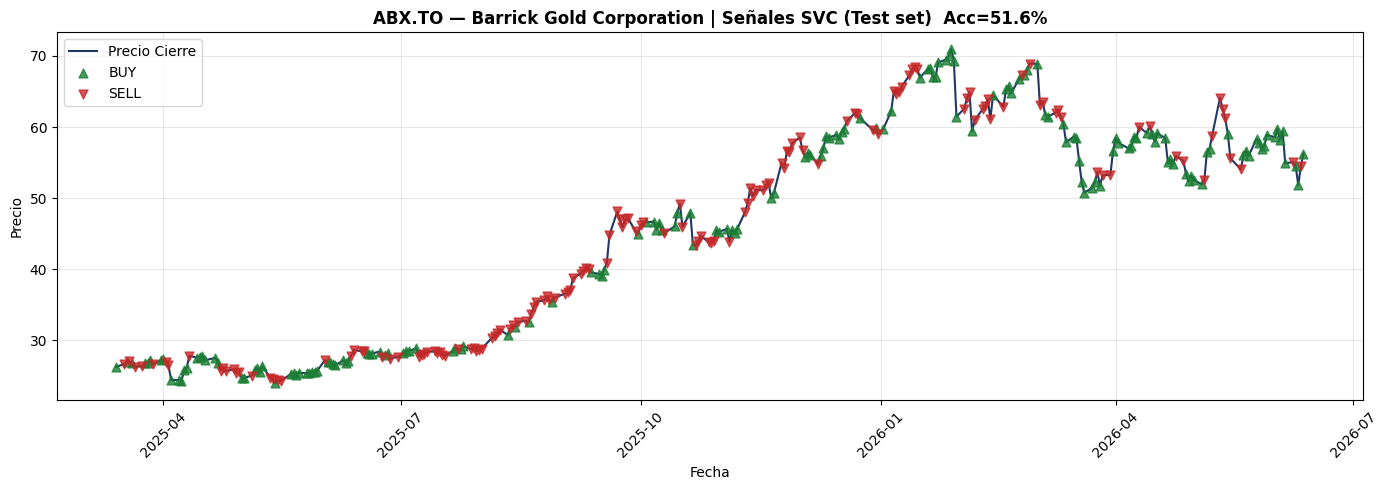

   BUY: 168  SELL: 146    Kernel: sigmoid  C=100  gamma=scale



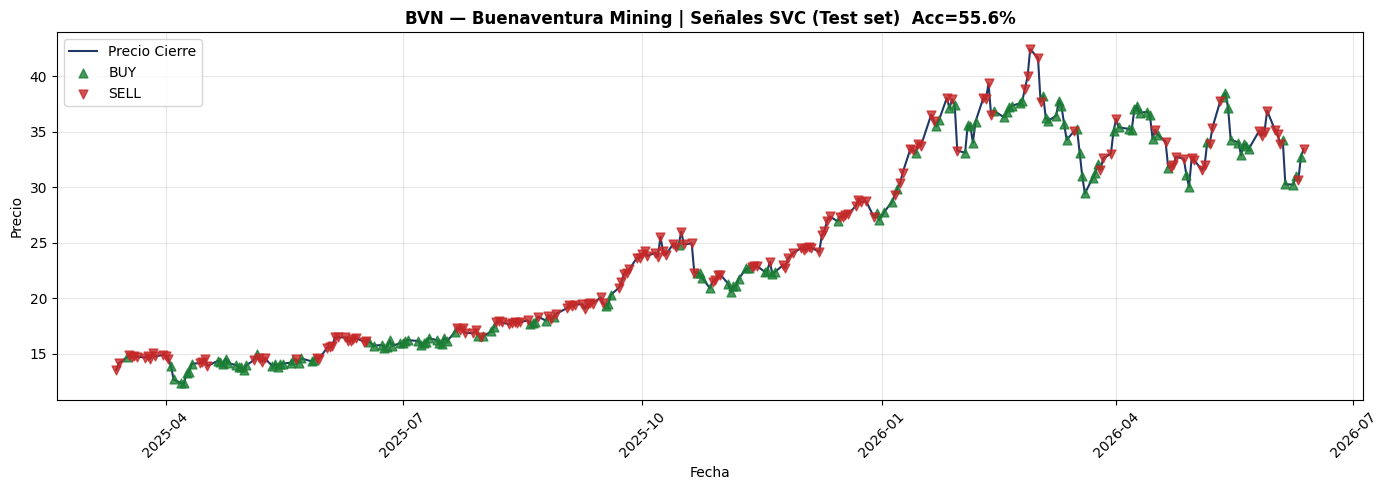

   BUY: 147  SELL: 168    Kernel: rbf  C=10  gamma=scale



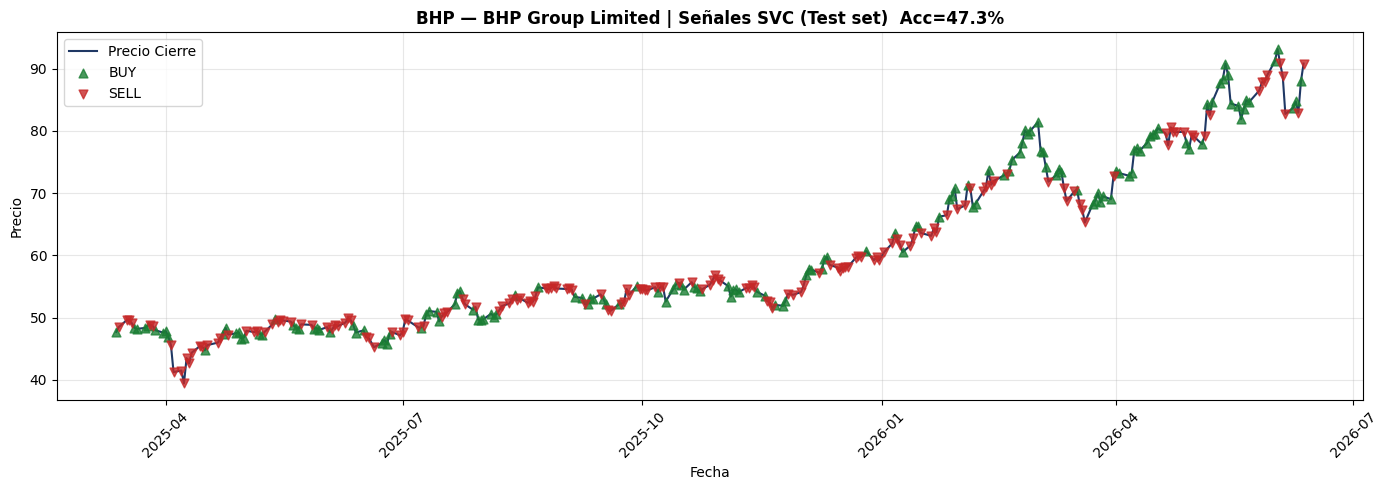

   BUY: 151  SELL: 164    Kernel: sigmoid  C=100  gamma=scale



In [15]:
# ═══════════════════════════════════════════════════════════════════════
# TABLA RESUMEN DE RESULTADOS
# ═══════════════════════════════════════════════════════════════════════

print('📋 TABLA RESUMEN — MÉTRICAS POR TICKER\n')
print(f'   {"Ticker":<14s}  {"Kernel":<8s}  {"C":>5s}  {"Gamma":<6s}  '
      f'{"Accuracy":>9s}  {"Precision":>9s}  {"Recall":>7s}  {"F1":>7s}')
print('   ' + '─'*75)

for ticker, res in resultados_svm.items():
    m = res['metricas']
    p = res['params']
    print(f'   {ticker:<14s}  {p["kernel"]:<8s}  {str(p["C"]):>5s}  '
          f'{p["gamma"]:<6s}  '
          f'{m["accuracy"]:>9.4f}  {m["precision"]:>9.4f}  '
          f'{m["recall"]:>7.4f}  {m["f1"]:>7.4f}')

print('\n')

# ═══════════════════════════════════════════════════════════════════════
# VISUALIZACIÓN: MATRICES DE CONFUSIÓN
# ═══════════════════════════════════════════════════════════════════════

n_tickers = len(resultados_svm)
fig, axes = plt.subplots(1, n_tickers, figsize=(4*n_tickers, 4))
if n_tickers == 1:
    axes = [axes]

for ax, (ticker, res) in zip(axes, resultados_svm.items()):
    cm = np.array(res['confusion_matrix'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['SELL', 'BUY'], yticklabels=['SELL', 'BUY'])
    ax.set_title(f'{ticker}\nKernel: {res["params"]["kernel"]}',
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Real')

plt.suptitle('Matrices de Confusión — SVC por Ticker', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════════════
# VISUALIZACIÓN: GRÁFICO DE PRECIOS + SEÑALES BUY/SELL
# ═══════════════════════════════════════════════════════════════════════

for ticker, res in resultados_svm.items():
    df_sig = res['df_test_sig']

    fig, ax = plt.subplots(figsize=(14, 5))

    # Línea de precios
    ax.plot(df_sig.index, df_sig['Close'], color='#1F3864',
            linewidth=1.5, label='Precio Cierre', zorder=2)

    # Marcadores BUY
    buy_mask  = df_sig['senal'] == 'BUY'
    sell_mask = df_sig['senal'] == 'SELL'
    ax.scatter(df_sig.index[buy_mask],  df_sig['Close'][buy_mask],
               color='#1b7e34', marker='^', s=40, label='BUY',  zorder=3, alpha=0.8)
    ax.scatter(df_sig.index[sell_mask], df_sig['Close'][sell_mask],
               color='#c62828', marker='v', s=40, label='SELL', zorder=3, alpha=0.8)

    ax.set_title(f'{ticker} — {EMPRESAS_META[ticker]["nombre"]} | '
                 f'Señales SVC (Test set)  Acc={res["metricas"]["accuracy"]:.1%}',
                 fontweight='bold')
    ax.set_xlabel('Fecha')
    ax.set_ylabel('Precio')
    ax.legend(loc='upper left')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.xticks(rotation=45)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    print(f'   BUY: {buy_mask.sum()}  SELL: {sell_mask.sum()}  '
          f'  Kernel: {res["params"]["kernel"]}  C={res["params"]["C"]}  gamma={res["params"]["gamma"]}\n')


# Modulo 9: Exportación a datos_svc.json

El JSON generado es **100% compatible** con `ernesto_investing_svc_clasificador.html`.

**Estructura del JSON:**
```json
{
  "generado_en": "2025-...",
  "tickers": {
    "FSM": {
      "nombre": "Fortuna Silver Mines",
      "fechas": [...],
      "precios": [...],
      "senales": ["BUY", "SELL", ...],
      "senal":  "BUY",         ← última señal
      "conf":   0.72,           ← confianza del modelo
      "metricas": {accuracy, precision, recall, f1},
      "matriz":  [[TP,FP],[FN,TN]],
      "clases":  {buy: N, sell: N},
      "kernel":  {tipo, C, gamma}
    },
    ...
  }
}\
```


In [16]:
# ═══════════════════════════════════════════════════════════════════════
# CONSTRUCCIÓN DEL OBJETO JSON COMPATIBLE CON EL HTML
# ═══════════════════════════════════════════════════════════════════════

print('💾 Construyendo datos_svc.json...\n')

datos_json = {
    'generado_en': datetime.now().strftime('%Y-%m-%dT%H:%M:%S'),
    'horizonte_dias': HORIZONTE_PREDICCION,
    'ratio_train': RATIO_TRAIN,
    'cv_folds': CV_FOLDS,
    'tickers': {}
}

for ticker, res in resultados_svm.items():

    df_sig = res['df_test_sig']

    # ── Listas para el gráfico de precios ──────────────────────────────
    fechas  = [d.strftime('%Y-%m-%d') for d in df_sig.index]
    precios = [round(float(p), 4) for p in df_sig['Close']]
    senales = list(df_sig['senal'])

    # ── Última señal y confianza ───────────────────────────────────────
    ultima_senal = senales[-1]
    ultima_prob  = float(res['y_prob'][-1])
    # Confianza = probabilidad de la clase predicha
    if ultima_senal == 'BUY':
        confianza = ultima_prob
    else:
        confianza = 1.0 - ultima_prob
    confianza = round(confianza, 4)

    # ── Matriz de confusión en formato [[TP,FP],[FN,TN]] ──────────────
    # sklearn devuelve [[TN,FP],[FN,TP]] — reordenamos para el HTML
    cm = np.array(res['confusion_matrix'])
    tn, fp, fn, tp = cm.ravel()
    matriz_html = [[int(tp), int(fp)], [int(fn), int(tn)]]

    # ── Distribución de clases ─────────────────────────────────────────
    n_buy  = int((df_sig['senal'] == 'BUY').sum())
    n_sell = int((df_sig['senal'] == 'SELL').sum())

    # ── Señales con probabilidad (uso futuro / panel avanzado) ─────────
    senales_detalle = [
        {'fecha': f, 'precio': p, 'senal': s, 'prob': round(float(pb), 4)}
        for f, p, s, pb in zip(fechas, precios, senales, res['y_prob'].tolist())
    ]

    datos_json['tickers'][ticker] = {
        # Identificación
        'nombre':  EMPRESAS_META[ticker]['nombre'],
        'moneda':  EMPRESAS_META[ticker]['moneda'],

        # Arrays para Chart.js (graficoPrecio)
        'fechas':  fechas,
        'precios': precios,
        'senales': senales,

        # Semáforo
        'senal': ultima_senal,
        'conf':  confianza,

        # Panel métricas
        'metricas': res['metricas'],

        # Matriz de confusión
        'matriz': matriz_html,

        # Gráfico de barras
        'clases': {'buy': n_buy, 'sell': n_sell},

        # Panel kernel
        'kernel': {
            'tipo':  res['params']['kernel'],
            'C':     res['params']['C'],
            'gamma': res['params']['gamma']
        },

        # Detalle de señales con probabilidades (uso avanzado)
        'senales_detalle': senales_detalle,

        # Metadatos del modelo
        'modelo_meta': {
            'n_train':     particiones[ticker]['n_train'],
            'n_test':      particiones[ticker]['n_test'],
            'fecha_corte': particiones[ticker]['fecha_corte'],
            'cv_f1_macro': round(float(res['cv_score']), 4),
            'n_features':  len(FEATURES),
        }
    }

    print(f'   ✅ {ticker:<14s}  señal={ultima_senal:<4s}  conf={confianza:.0%}  '
          f'acc={res["metricas"]["accuracy"]:.1%}  '
          f'kernel={res["params"]["kernel"]}')

# ── Guardar JSON ───────────────────────────────────────────────────────
ruta_json = 'datos_svc.json'
with open(ruta_json, 'w', encoding='utf-8') as f:
    json.dump(datos_json, f, ensure_ascii=False, indent=2, default=str)

tamanio_kb = __import__('os').path.getsize(ruta_json) / 1024
print(f'\n✅ Exportado: {ruta_json}  ({tamanio_kb:.1f} KB)')
print(f'   Tickers incluidos : {list(datos_json["tickers"].keys())}')
print(f'   Generado en       : {datos_json["generado_en"]}')


💾 Construyendo datos_svc.json...

   ✅ FSM             señal=BUY   conf=49%  acc=51.4%  kernel=sigmoid
   ✅ VOLCABC1.LM     señal=SELL  conf=61%  acc=45.9%  kernel=poly
   ✅ ABX.TO          señal=BUY   conf=50%  acc=51.6%  kernel=sigmoid
   ✅ BVN             señal=SELL  conf=54%  acc=55.6%  kernel=rbf
   ✅ BHP             señal=SELL  conf=47%  acc=47.3%  kernel=sigmoid

✅ Exportado: datos_svc.json  (286.0 KB)
   Tickers incluidos : ['FSM', 'VOLCABC1.LM', 'ABX.TO', 'BVN', 'BHP']
   Generado en       : 2026-06-14T23:26:35


# Modulo 10: Descarga del JSON desde COLAB

Ejecuta la celda siguiente para descargar `datos_svc.json` a tu equipo local.
Luego colócalo en la **misma carpeta** que `ernesto_investing_svc_clasificador.html`
y modifica el script del HTML para cargarlo con `fetch('datos_svc.json')`.


In [17]:
# ── Descarga automática desde Colab ───────────────────────────────────
from google.colab import files
files.download('datos_svc.json')
print('✅ Descarga iniciada — revisa la carpeta de descargas de tu navegador')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Descarga iniciada — revisa la carpeta de descargas de tu navegador


# Modulo 11: Guía de Integración con el HTML

Para conectar el JSON generado con `ernesto_investing_svc_clasificador.html`,
reemplaza el bloque `MÓDULO 1: DATOS POR TICKER (SIMULADOS)` del HTML con:

```javascript
// ═══════════════════════════════════════════════════════════════════
// MÓDULO 1: CARGA DE DATOS REALES DESDE datos_svc.json
// ═══════════════════════════════════════════════════════════════════
let DATA_SVC = null;

async function cargarDatos() {
  const resp = await fetch('datos_svc.json');
  DATA_SVC = await resp.json();
  renderizar();  // Renderizar con datos reales
}

function getDatosTicker(ticker) {
  return DATA_SVC.tickers[ticker];  // Estructura idéntica al mock
}

// Llamar al cargar la página
cargarDatos();
```

Y en `renderizar()` cambiar:
```javascript
// ANTES (simulado):
const datos = generarDatosTicker(TICKERS[ticker]);

// DESPUÉS (real):
const datos = getDatosTicker(ticker);
```

---

✅ Campos garantizados en `datos_svc.json`

| Campo | Tipo | Descripción |
|-------|------|-------------|
| `fechas` | `string[]` | Fechas del test set (`YYYY-MM-DD`) |
| `precios` | `number[]` | Precios de cierre |
| `senales` | `string[]` | `'BUY'` o `'SELL'` por fecha |
| `senal` | `string` | Última señal del modelo |
| `conf` | `number` | Confianza `[0,1]` de la señal actual |
| `metricas` | `object` | `{accuracy, precision, recall, f1}` |
| `matriz` | `number[][]` | `[[TP,FP],[FN,TN]]` |
| `clases` | `object` | `{buy: N, sell: N}` |
| `kernel` | `object` | `{tipo, C, gamma}` del mejor modelo |

